In [ ]:
from google.colab import files
uploaded = files.upload()

Saving LLM Validated.csv to LLM Validated (2).csv
Saving Raw Evaluation.csv to Raw Evaluation (2).csv


In [ ]:
import pandas as pd

raw_df = pd.read_csv('Raw Evaluation.csv')
gen_df = pd.read_csv('LLM Validated.csv')

raw_df.columns = raw_df.columns.str.lower().str.strip()
gen_df.columns = gen_df.columns.str.lower().str.strip()


In [ ]:
import re
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return []
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    stopwords = {'the', 'is', 'in', 'at', 'of', 'a', 'an', 'and', 'to', 'for'}
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords]

    return tokens


In [ ]:
def compute_metrics(orig_tokens, gen_tokens):
    o_set = set(orig_tokens)
    g_set = set(gen_tokens)

    tp = len(o_set & g_set)
    fp = len(g_set - o_set)
    fn = len(o_set - g_set)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy = len(o_set & g_set) / len(o_set | g_set) if (o_set | g_set) else 1.0

    return precision, recall, f1, accuracy


In [ ]:
fields_to_compare = ['title', 'creator', 'description', 'subject', 'contributor', 'date', 'type', 'language']
results = []

for field in fields_to_compare:
    raw_tokens = raw_df[field].apply(clean_text)
    gen_tokens = gen_df[field].apply(clean_text)

    precisions, recalls, f1s, accuracies = [], [], [], []

    for o, g in zip(raw_tokens, gen_tokens):
        p, r, f1, acc = compute_metrics(o, g)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)
        accuracies.append(acc)

    results.append({
        'Field': field.title(),
        'Precision': round(sum(precisions) / len(precisions), 4),
        'Recall': round(sum(recalls) / len(recalls), 4),
        'F1-Score': round(sum(f1s) / len(f1s), 4),
        'Accuracy': round(sum(accuracies) / len(accuracies), 4)
    })

metrics_df = pd.DataFrame(results)
metrics_df


,Field,Precision,Recall,F1-Score,Accuracy
0,Title,1.0000,1.0000,1.0000,1.0000
1,Creator,0.5241,0.8556,0.6191,0.5091
2,Description,0.2623,0.5752,0.3312,0.2043
3,Subject,0.4522,0.5937,0.4989,0.3693
4,Contributor,0.0000,0.0000,0.0000,0.0000
5,Date,0.4000,0.4000,0.4000,0.4000
6,Type,0.1667,0.2667,0.2000,0.1667
7,Language,0.0000,0.0000,0.0000,0.0000


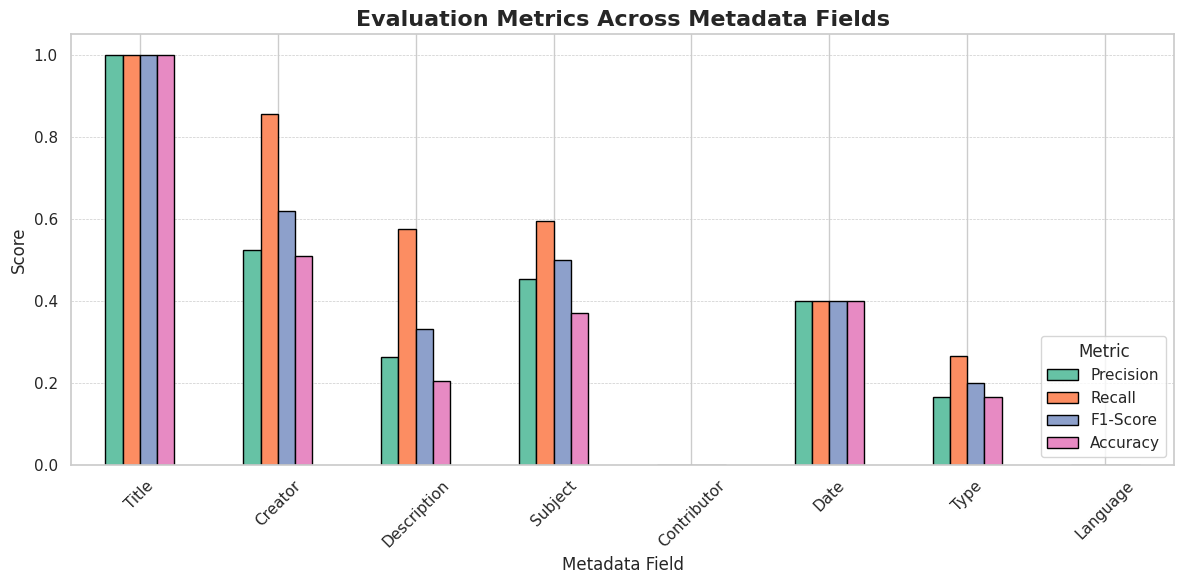

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid", palette="muted")

colors = sns.color_palette("Set2", 4)  # 4 distinct pastel colors

ax = metrics_df.set_index('Field')[['Precision', 'Recall', 'F1-Score', 'Accuracy']].plot(
    kind='bar',
    figsize=(12, 6),
    rot=45,
    color=colors,
    edgecolor='black'
)

plt.title('Evaluation Metrics Across Metadata Fields', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metadata Field', fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Metric', title_fontsize=12, fontsize=11, loc='lower right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', linewidth=0.5)

plt.show()


In [ ]:

from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-mpnet-base-v2')

def calculate_semantic_similarity(text1, text2):
    embedding1 = model.encode(text1, convert_to_tensor=True)
    embedding2 = model.encode(text2, convert_to_tensor=True)

    cosine_scores = util.cos_sim(embedding1, embedding2)

    return cosine_scores.item()

fields_to_compare = ['title', 'creator', 'description', 'subject', 'contributor', 'date', 'type', 'language']
results = []

for field in fields_to_compare:
    raw_texts = raw_df[field].astype(str).tolist()
    gen_texts = gen_df[field].astype(str).tolist()

    similarities = []

    for raw_text, gen_text in zip(raw_texts, gen_texts):
        similarity = calculate_semantic_similarity(raw_text, gen_text)
        similarities.append(similarity)

    results.append({
        'Field': field.title(),
        'Semantic Similarity': round(sum(similarities) / len(similarities), 4)
    })

semantic_similarity_df = pd.DataFrame(results)
print(semantic_similarity_df)

         Field  Semantic Similarity
0        Title               1.0000
1      Creator               0.6827
2  Description               0.8144
3      Subject               0.7801
4  Contributor               0.1980
5         Date               0.6601
6         Type               0.5732
7     Language               0.5318


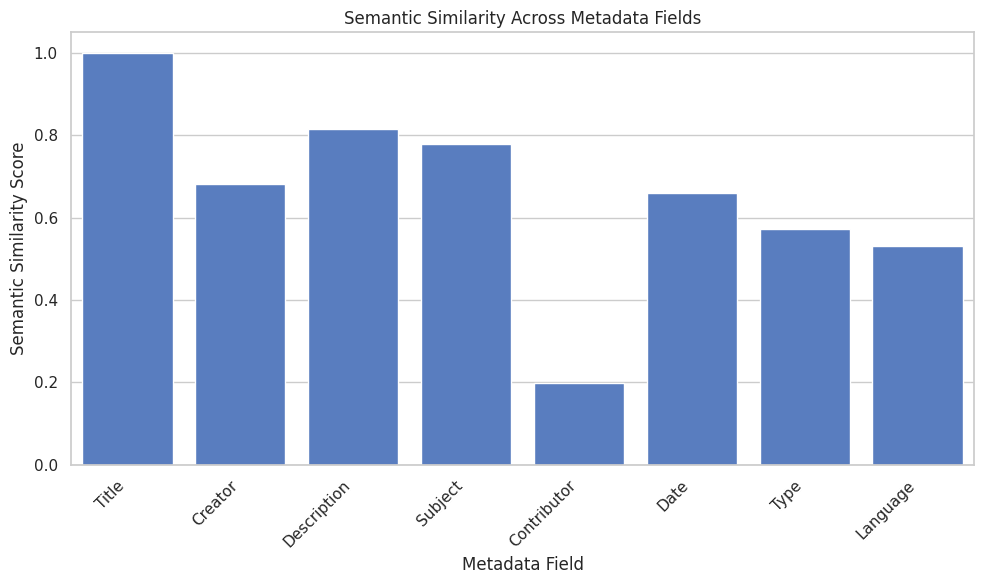

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Field', y='Semantic Similarity', data=semantic_similarity_df)
plt.xticks(rotation=45, ha='right')
plt.title('Semantic Similarity Across Metadata Fields')
plt.ylabel('Semantic Similarity Score')
plt.xlabel('Metadata Field')
plt.tight_layout()
plt.show()
